In [1]:
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import numpy as np

In [2]:
model = pm.Model()
with model:
    y_data = pm.MutableData(name="y_data", value=np.zeros(1))
    x = pm.Normal("x", mu=0, sigma=1)
    y = pm.Normal("y", mu=x, sigma=1, observed=y_data)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [x]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


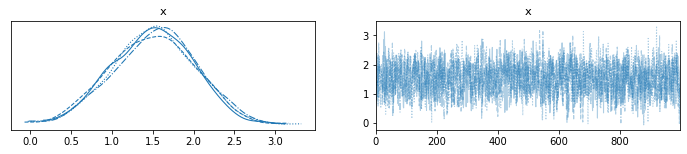

In [4]:
with model:
    pm.set_data({"y_data": np.array([1, 2, 3])})
    trace = pm.sample(1000, tune=1000, return_inferencedata=True)
    az.plot_trace(trace)